In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

# Shifted Framework Analysis

This notebook studies how the shift parameter changes shifted-Black and shifted-SABR pricing results. The goal is to understand whether shift is merely a technical fix or an economically meaningful modeling choice.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from swaption_pricing.pricing.european import price_swaption_shifted_black
from swaption_pricing.market import bootstrap_zero_curve
from swaption_pricing.pricing.european import SabrParams, price_swaption_with_shifted_sabr
from swaption_pricing.types import MarketQuote, SwaptionSpec

## 1. Base Setup

In [3]:
quotes = [
    MarketQuote(instrument_type='deposit', maturity=1.0, rate=0.0420),
    MarketQuote(instrument_type='swap', maturity=2.0, rate=0.0415, pay_frequency=1),
    MarketQuote(instrument_type='swap', maturity=3.0, rate=0.0410, pay_frequency=1),
    MarketQuote(instrument_type='swap', maturity=4.0, rate=0.0408, pay_frequency=1),
    MarketQuote(instrument_type='swap', maturity=5.0, rate=0.0405, pay_frequency=1),
    MarketQuote(instrument_type='swap', maturity=6.0, rate=0.0403, pay_frequency=1),
    MarketQuote(instrument_type='swap', maturity=7.0, rate=0.0402, pay_frequency=1),
]
curve = bootstrap_zero_curve(quotes)
params = SabrParams(alpha=0.0200, beta=0.50, rho=-0.25, nu=0.40)
shifts = [0.01, 0.02, 0.03, 0.05]

payer_spec = SwaptionSpec(notional=10_000_000.0, expiry=2.0, tenor=5.0, strike=0.0400, pay_frequency=1, option_type='payer')
receiver_spec = SwaptionSpec(notional=10_000_000.0, expiry=2.0, tenor=5.0, strike=0.0400, pay_frequency=1, option_type='receiver')

## 2. Shift Sensitivity Table

In [4]:
rows = []
for shift in shifts:
    for spec in [payer_spec, receiver_spec]:
        shifted_black = price_swaption_shifted_black(curve, spec, vol=0.20, shift=shift)
        shifted_sabr_price, shifted_sabr_vol = price_swaption_with_shifted_sabr(curve, spec, params, shift)
        rows.append({
            'shift': shift,
            'option_type': spec.option_type,
            'shifted_black_price': shifted_black,
            'shifted_sabr_vol': shifted_sabr_vol,
            'shifted_sabr_price': shifted_sabr_price,
        })

shift_df = pd.DataFrame(rows)
shift_df

,shift,option_type,shifted_black_price,shifted_sabr_vol,shifted_sabr_price
0,0.01,payer,222020.435702,0.091212,97271.257436
1,0.01,receiver,238266.452497,0.091212,113517.274231
2,0.02,payer,268198.753527,0.083281,107405.568740
3,0.02,receiver,284444.770322,0.083281,123651.585535
4,0.03,payer,314381.386478,0.077116,116724.527048
5,0.03,receiver,330627.403273,0.077116,132970.543843
6,0.05,payer,406753.832197,0.068030,133544.160268
7,0.05,receiver,422999.848993,0.068030,149790.177063


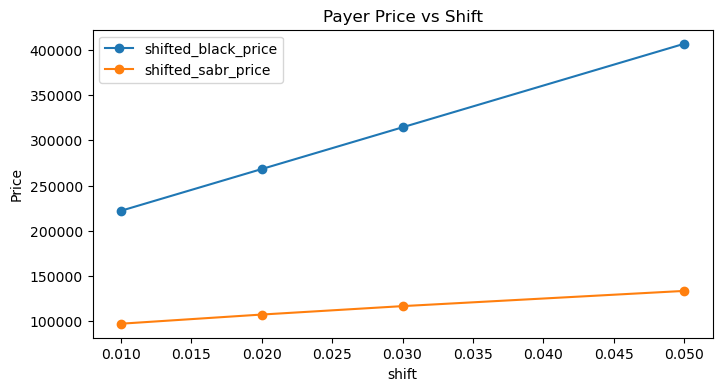

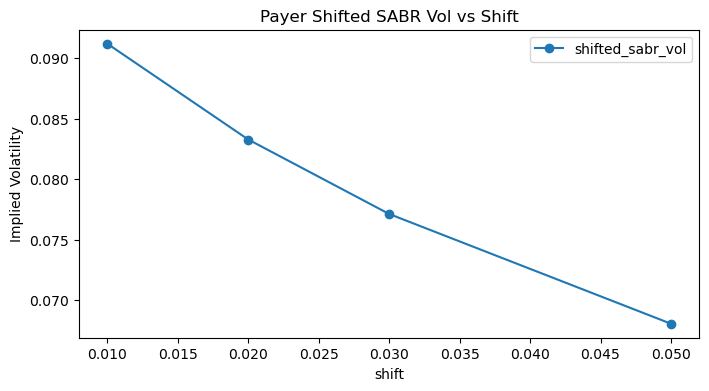

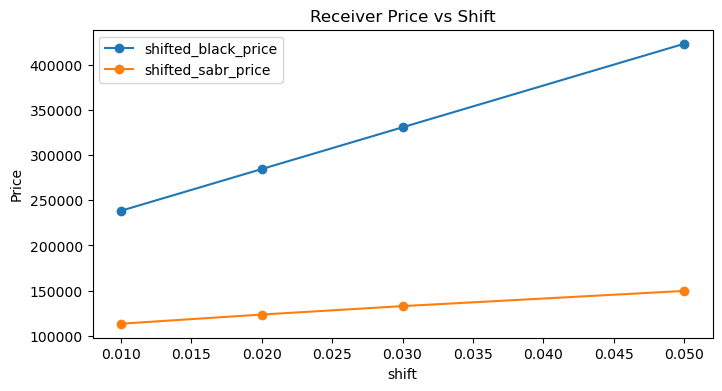

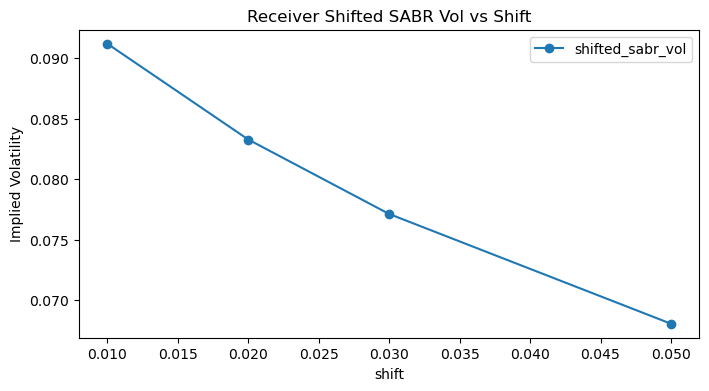

In [5]:
for option_type in ['payer', 'receiver']:
    subset = shift_df[shift_df['option_type'] == option_type]
    ax = subset.plot(x='shift', y=['shifted_black_price', 'shifted_sabr_price'], marker='o', figsize=(8, 4), title=f'{option_type.title()} Price vs Shift')
    ax.set_ylabel('Price')
    plt.show()

    ax = subset.plot(x='shift', y='shifted_sabr_vol', marker='o', figsize=(8, 4), title=f'{option_type.title()} Shifted SABR Vol vs Shift')
    ax.set_ylabel('Implied Volatility')
    plt.show()

## 3. Interpretation

- The shift is not just a numerical patch; it changes the effective lognormalization of forward and strike.
- As the shift changes, both shifted-Black price and shifted-SABR implied vol can move.
- The magnitude and direction of the impact can differ between payer and receiver structures.

This means shift should be treated as a modeling choice and documented as part of the low-rate framework.